In [1]:
# importing the libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import zipfile
import shutil
import PIL.Image as Image

In [2]:
# importing the data
if not os.path.exists('./horse2zebra'):
  import gdown
  url = 'https://drive.google.com/uc?id=1jPelB2jzNZJq3ZU9Uk_Mkt4MJtF3DRgg'
  gdown.download(url, './horse2zebra.zip', quiet=False)
  !unzip ./horse2zebra.zip > /dev/null

Downloading...
From (original): https://drive.google.com/uc?id=1jPelB2jzNZJq3ZU9Uk_Mkt4MJtF3DRgg
From (redirected): https://drive.google.com/uc?id=1jPelB2jzNZJq3ZU9Uk_Mkt4MJtF3DRgg&confirm=t&uuid=7d2b0882-d9a4-417b-9da0-cc937a43d820
To: /content/horse2zebra.zip
100%|██████████| 117M/117M [00:02<00:00, 52.2MB/s]


In [3]:
# extracting the training images
for root, dirs, files in os.walk('./horse2zebra'):
    if root.endswith('/train/A'):
        filenames_horses=files
    if root.endswith('/train/B'):
        filenames_zebras=files

# sorting the filenames
filenames_horses_sort=sorted(filenames_horses)
filenames_zebras_sort=sorted(filenames_zebras)

horses_root='./horse2zebra/train/A'
zebras_root='./horse2zebra/train/B'

horses_train=[]
zebras_train=[]

# saving all the images in the appropriate directories
for i in range(len(filenames_horses_sort)):
          horses_train.append(Image.open(os.path.join(horses_root, filenames_horses_sort[i])).convert('RGB'))

for i in range(len(filenames_zebras_sort)):
          zebras_train.append(Image.open(os.path.join(zebras_root, filenames_zebras_sort[i])).convert('RGB'))

train_dir = './horse2zebra/train'

In [4]:
# extracting the testing images
for root, dirs, files in os.walk('./horse2zebra'):
    if root.endswith('/test/A'):
        filenames_horses=files
    if root.endswith('/test/B'):
        filenames_zebras=files

# sorting the filenames
filenames_horses_sort=sorted(filenames_horses)
filenames_zebras_sort=sorted(filenames_zebras)

horses_root='./horse2zebra/test/A'
zebras_root='./horse2zebra/test/B'

horses_test=[]
zebras_test=[]

# saving all the images in the appropriate directories
for i in range(len(filenames_horses_sort)):
          horses_test.append(Image.open(os.path.join(horses_root, filenames_horses_sort[i])).convert('RGB'))

for i in range(len(filenames_zebras_sort)):
          zebras_test.append(Image.open(os.path.join(zebras_root, filenames_zebras_sort[i])).convert('RGB'))

test_dir = './horse2zebra/test'

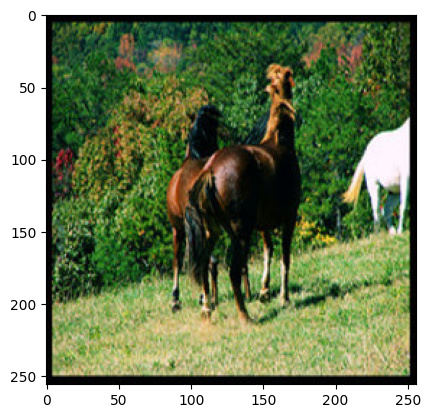

In [5]:
# printing out one image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
plt.imshow(mpimg.imread(os.path.join(horses_root, filenames_horses_sort[0])))

Now, since we don't really have a validation set, we create a validation set and move the first 100 images from the training set to the validation set using functions from the os library.


In [6]:
# creating a validation dir
val_dir = os.path.join('./horse2zebra', 'val')
val_horse_dir = os.path.join(val_dir, 'A')
val_zebra_dir = os.path.join(val_dir, 'B')
os.mkdir(val_dir)
os.mkdir(os.path.join(val_dir,'A'))
os.mkdir(os.path.join(val_dir, 'B'))


# obtaining the iamge names in traing dir
train_horse_dir = os.path.join(train_dir, 'A')
train_horse_fnames = os.listdir(train_horse_dir)
train_zebra_dir = os.path.join(train_dir, 'B')
train_zebra_fnames = os.listdir(train_zebra_dir)


# moving the first 100 images to the corresponding validation data folder
for i in range(100):
  shutil.move(os.path.join(train_horse_dir,train_horse_fnames[i]),val_horse_dir)
  shutil.move(os.path.join(train_zebra_dir,train_zebra_fnames[i]),val_zebra_dir)

In [7]:
# creating pipelines to generate and normalize the images
import tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(rescale = 1./255)
test_datagen  = ImageDataGenerator(rescale = 1./255)
val_datagen   = ImageDataGenerator(rescale = 1./255)

**VGG-16**

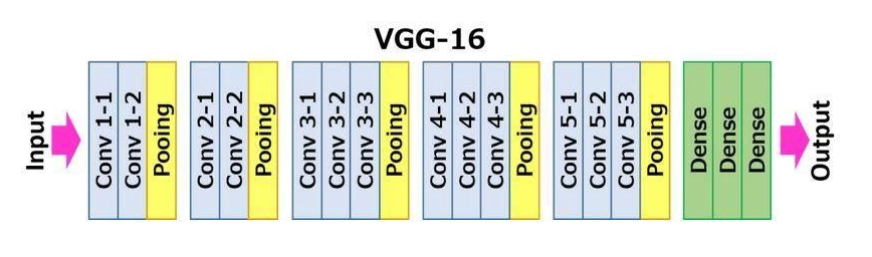

To begin, we implement the previously created data generators to generate the train, test, and validation sets and resize the images to 224x224 for the network implementatio

In [8]:
# flow training in batches of 20 train_datagen
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224), # rescaling the images to 224x224
        batch_size=20,
        class_mode='categorical')

Found 2201 images belonging to 2 classes.


In [9]:
# flow validation images in batches of 20 using val_datagen
val_generator = val_datagen.flow_from_directory(
        val_dir,
        target_size=(224, 224), # rescaling the images to 224x224
        batch_size=20,
        class_mode='categorical')

Found 200 images belonging to 2 classes.


In [10]:
# flow test images in batches of 20 using datagen
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (224, 224),
    batch_size = 20,
    class_mode = 'categorical'
)

Found 260 images belonging to 2 classes.


**Next, we use the concept of Transfer Learning to use VGG-16's pre-trained weights and biases for image classification. To do this, we import the base model of VGG-16 from the Keras library.**

In [11]:
# importing the network
from keras.applications.vgg16 import VGG16
base_model = VGG16(input_shape =  (224,224,3), weights = 'imagenet', include_top = False)
base_model.trainable = False   # freezing layers
base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

**After that, we add in a Deep Neural Network at the tail of the base model which flattens the features generated during convolution to make predictions using 2 nodes and the 'sigmoid' activation. We also compile the model and set the optimizer to be 'adam' with learning rate to be 0.0001, loss to be 'categorical_crossentropy' and metric to be 'accuracy'**

In [12]:
# adding a deep neural network to make preditions
import tensorflow as tf

# adding a deep neural network to make predictions
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(2, activation='sigmoid')
])
model.summary()

# compiling the network
model.compile(loss = 'categorical_crossentropy',
              optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001),
              metrics = ['acc'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

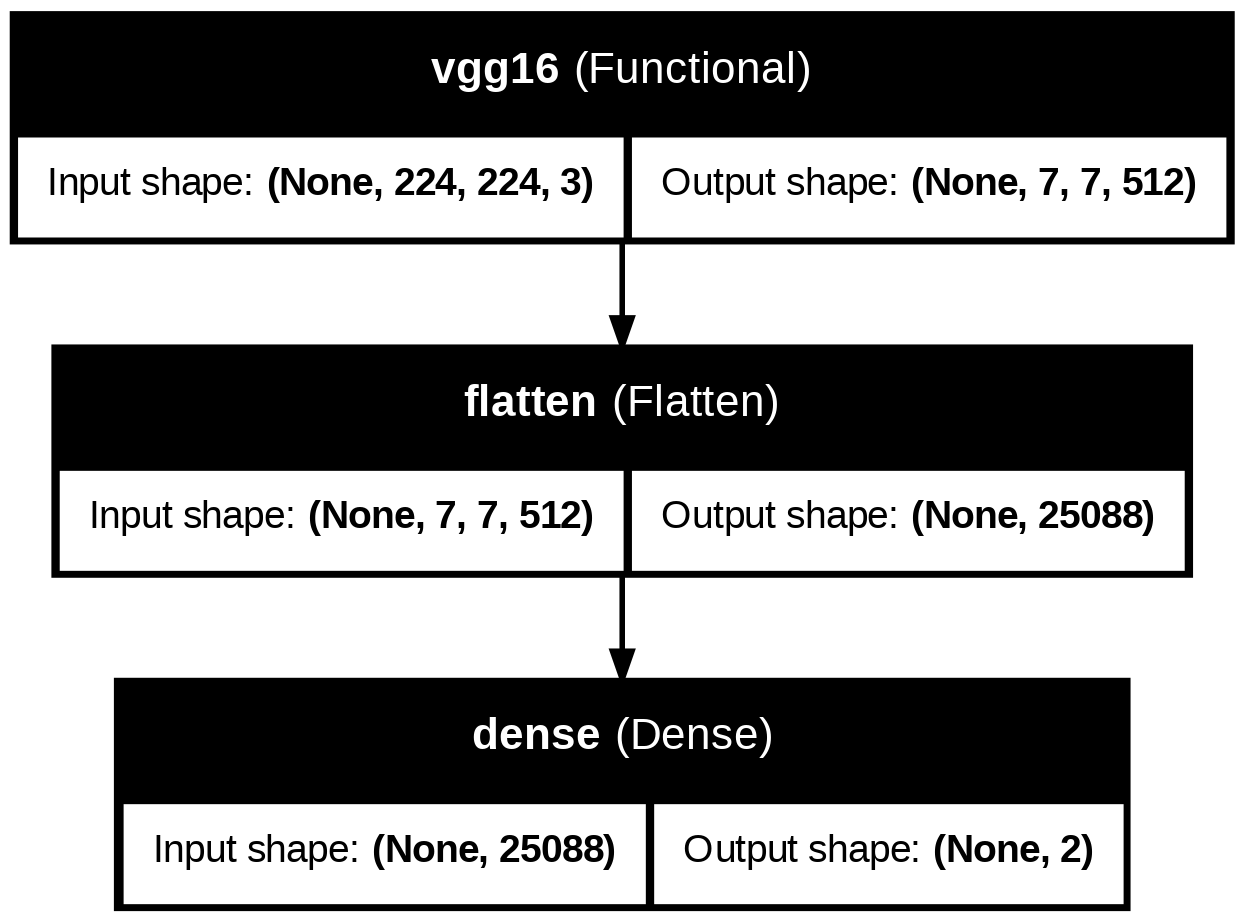

In [13]:
# obtaining pictorial representation of the network
from tensorflow.keras.utils import plot_model
plot_model(model,  show_shapes=True, show_layer_names=True)



**After that, we train the model on the training data generator with number of epochs set to 10 (optimum value set after trial and error of various combinations of accuracy and loss) and validation data to be used from the validation data generator.**

In [14]:
history = model.fit(train_generator,
                    epochs = 10,
                    validation_data =val_generator)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 30s 154ms/step - acc: 0.8737 - loss: 0.3161 - val_acc: 0.9350 - val_loss: 0.1809
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 14s 130ms/step - acc: 0.9482 - loss: 0.1608 - val_acc: 0.9500 - val_loss: 0.1325
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step - acc: 0.9687 - loss: 0.1220 - val_acc: 0.9700 - val_loss: 0.1225
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 141ms/step - acc: 0.9727 - loss: 0.0997 - val_acc: 0.9750 - val_loss: 0.0999
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - acc: 0.9741 - loss: 0.0869 - val_acc: 0.9750 - val_loss: 0.0930
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - acc: 0.9836 - loss: 0.0733 - val_acc: 0.9750 - val_loss: 0.0864
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - acc: 0.9859 - loss: 0.0650 - val_acc: 0.9750 - val_loss: 0.0810
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - acc: 0.9864 - loss: 0.0594 - val_acc: 0.9750 - val_loss: 0.0830
Epoch 9/10
111/111 ━━━━━━━━━━━━━

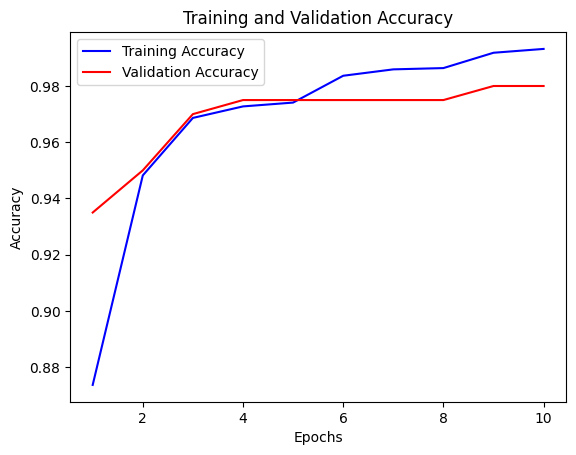

In [17]:
ta = history.history['acc']
va = history.history['val_acc']
epochs = range(1,11)

plt.figure()
plt.plot(epochs ,ta, 'b', label = 'Training Accuracy')
plt.plot(epochs ,va, 'r', label = 'Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

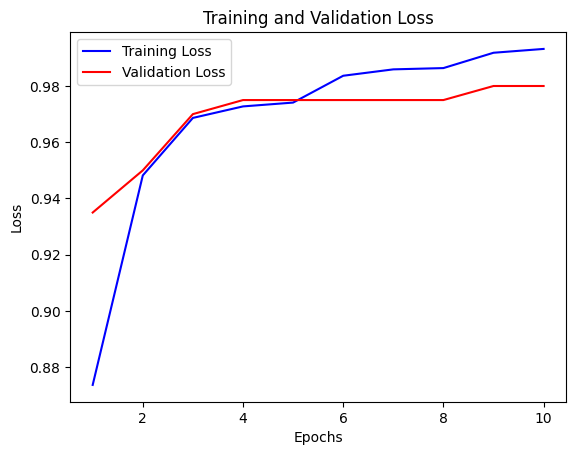

In [18]:
tl = history.history['loss']
vl = history.history['val_loss']
epochs = range(1,11)

plt.figure()
plt.plot(epochs ,ta, 'b', label = 'Training Loss')
plt.plot(epochs ,va, 'r', label = 'Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**To evaluate the performance of the model on the test set, we use the evaluate() function and print the model's accuracy on the testing set.**

In [ ]:
print(str.format('Accuracy on the Test Set: {:.2f}%', model.evaluate(test_generator)[1]*100))

***GoogleNet***

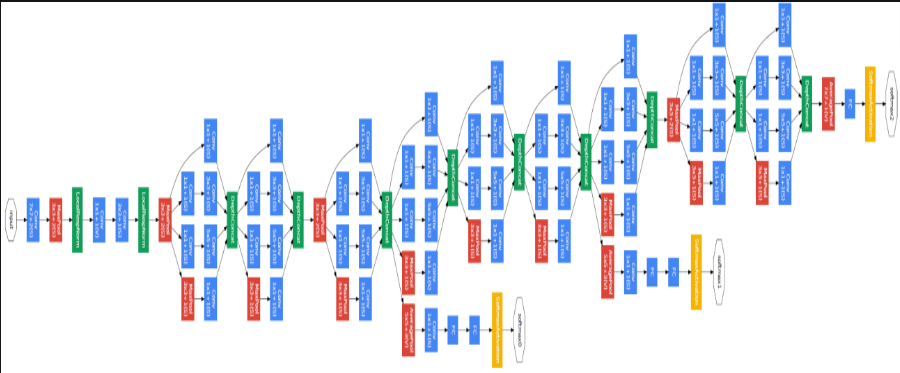

**To begin, we implement the previously created data generators to generate the train, test, and validation sets and resize the images to 299x299 for the network implementation.**

In [19]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size = (299,299),
    batch_size = 20,
    class_mode = 'categorical'
)

Found 2201 images belonging to 2 classes.


In [20]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size = (299,299),
    batch_size = 20,
    class_mode = 'categorical'
)

Found 200 images belonging to 2 classes.


In [21]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size = (299,299),
    batch_size = 20,
    class_mode = 'categorical'
)

Found 260 images belonging to 2 classes.


In [22]:
# importing the model transf
from keras.applications.inception_v3 import InceptionV3

base_model = InceptionV3(
    weights = 'imagenet',
    include_top = False,
    input_shape = (299,299,3)
)

base_model.trainable =  False   # freezing layers
base_model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

**After that, we add in a Deep Neural Network at the tail of the base model which flattens the features generated during convolution to make predictions using 2 nodes and the 'sigmoid' activation. We also compile the model and set the optimizer to be 'adam' with learning rate to be 0.0001, loss to be 'categorical_crossentropy' and metric to be 'accuracy'.**

In [25]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(2, activation = 'sigmoid')
])

model.summary()

# compiling the network
model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), metrics = ['acc'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │       262,146 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,064,930 (84.17 MB)

 Trainable params: 262,146 (1.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

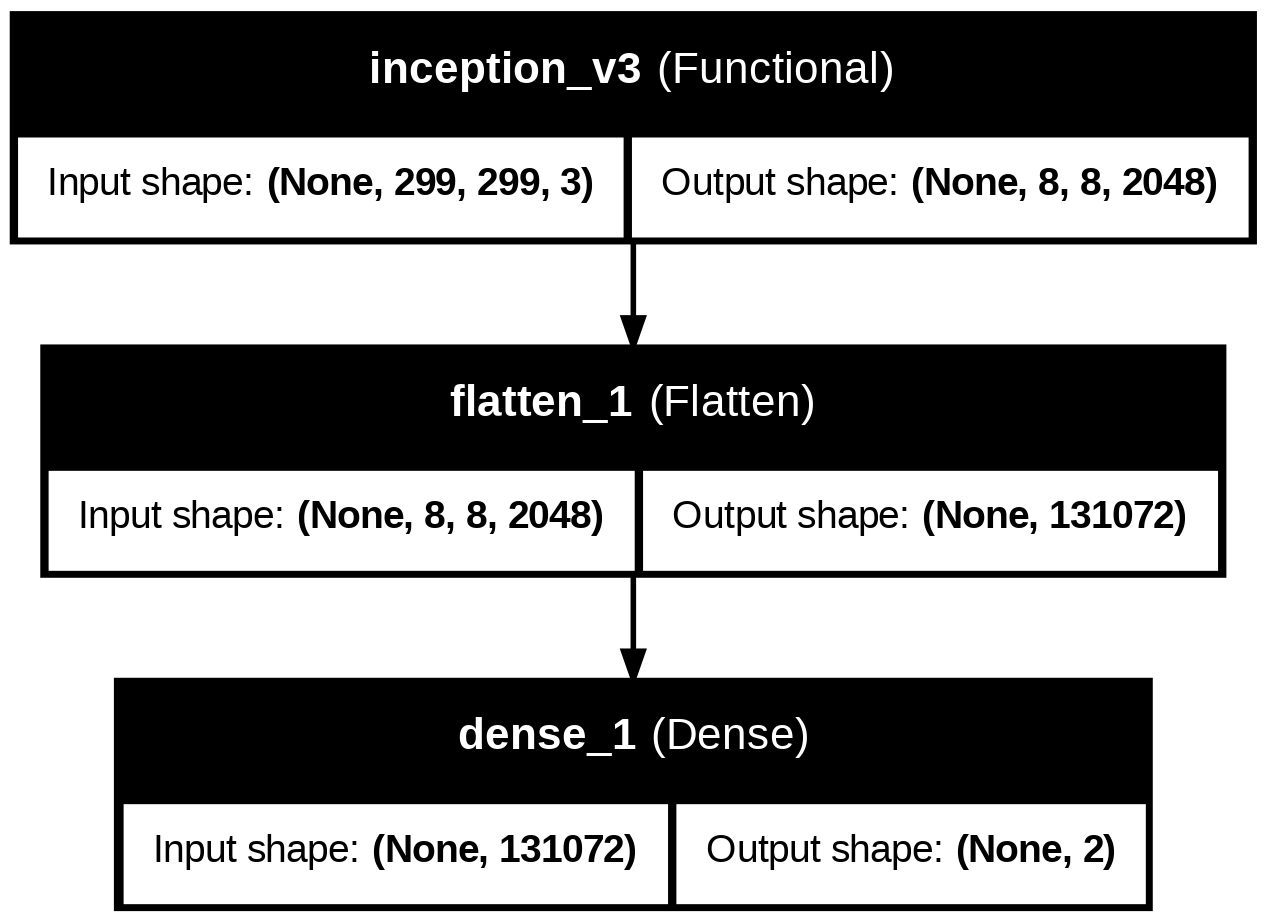

In [26]:
# obtaining a pictorial representation of the network
from tensorflow.keras.utils import plot_model
plot_model(model,  show_shapes=True, show_layer_names=True)

**After that, we train the model on the training data generator with number of epochs set to 10 (optimum value set after trial and error of various combinations of accuracy and loss) and validation data to be used from the validation data generator**

In [27]:
# training the network
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 46s 262ms/step - acc: 0.9764 - loss: 0.0623 - val_acc: 0.9900 - val_loss: 0.0170
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 93ms/step - acc: 0.9973 - loss: 0.0059 - val_acc: 0.9950 - val_loss: 0.0332
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/step - acc: 1.0000 - loss: 5.4284e-04 - val_acc: 0.9900 - val_loss: 0.0268
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - acc: 1.0000 - loss: 1.9896e-04 - val_acc: 0.9900 - val_loss: 0.0240
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 97ms/step - acc: 1.0000 - loss: 5.3830e-05 - val_acc: 0.9900 - val_loss: 0.0234
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - acc: 1.0000 - loss: 4.1291e-05 - val_acc: 0.9900 - val_loss: 0.0231
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 10s 92ms/step - acc: 1.0000 - loss: 3.4669e-05 - val_acc: 0.9900 - val_loss: 0.0225
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - acc: 1.0000 - loss: 3.0972e-05 - val_acc: 0.9900 - val_loss: 0.0225
Epoch 9/10
111

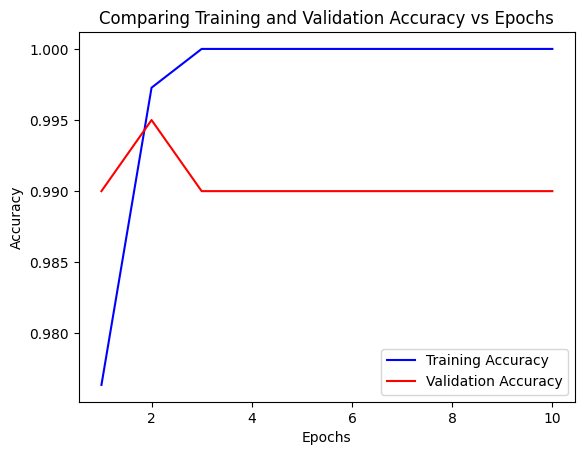

In [28]:
# extracting the model accuracy against epochs
ta = history.history['acc']
va = history.history['val_acc']
epochs = range(1,11)

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'b', label='Training Accuracy')
plt.plot(epochs, va, 'r', label='Validation Accuracy')
plt.title('Comparing Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

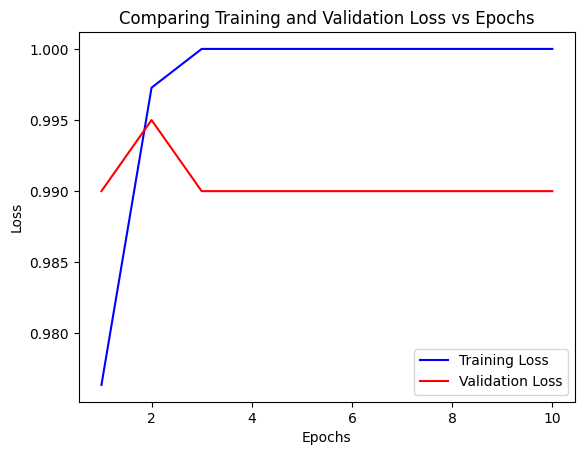

In [30]:
# extracting the model accuracy against epochs
tl = history.history['loss']
vl = history.history['val_loss']
epochs = range(1,11)

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'b', label='Training Loss')
plt.plot(epochs, va, 'r', label='Validation Loss')
plt.title('Comparing Training and Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [31]:
# evaluating the model on the testing set
print(str.format('Accuracy on Test Set: {:.2f}%', model.evaluate(test_generator)[1]*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - acc: 0.9846 - loss: 0.0893
Accuracy on Test Set: 98.46%


**ResNet50**

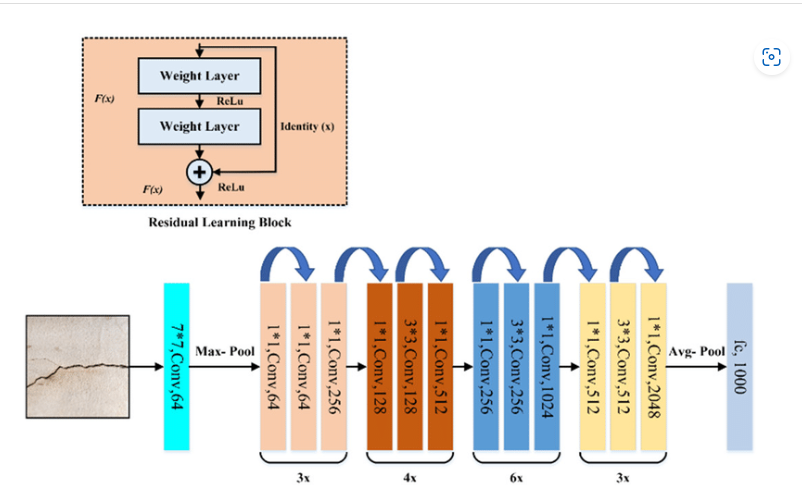

In [32]:
# flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224), # resclaing the images to 224 x 224
        batch_size=20,
        class_mode='categorical')

Found 2201 images belonging to 2 classes.


In [33]:
# flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224), # resclaing the images to 224 x 224
        batch_size=20,
        class_mode='categorical')

Found 2201 images belonging to 2 classes.


In [34]:
# flow validation images in batches of 20 using val_datagen generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224), # resclaing the images to 224 x 224
    batch_size=20,
    class_mode='categorical'
)

Found 200 images belonging to 2 classes.


In [35]:
# importing the network
from keras.applications.resnet import ResNet50
base_model = ResNet50(input_shape=(224,224,3), weights='imagenet', include_top=False)
base_model.trainable = False # freezing the layers
base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

**After that, we add in a Deep Neural Network at the tail of the base model which flattens the features generated during convolution to make predictions using 2 nodes and the 'sigmoid' activation. We also compile the model and set the optimizer to be 'adam' with learning rate to be 0.0001, loss to be 'categorical_crossentropy' and metric to be 'accuracy'**

In [36]:
# adding a deep neural network to make predictions
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(2, activation='sigmoid')
])
model.summary()

# compiling the network
model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), metrics = ['acc'])

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │       200,706 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,788,418 (90.75 MB)

 Trainable params: 200,706 (784.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

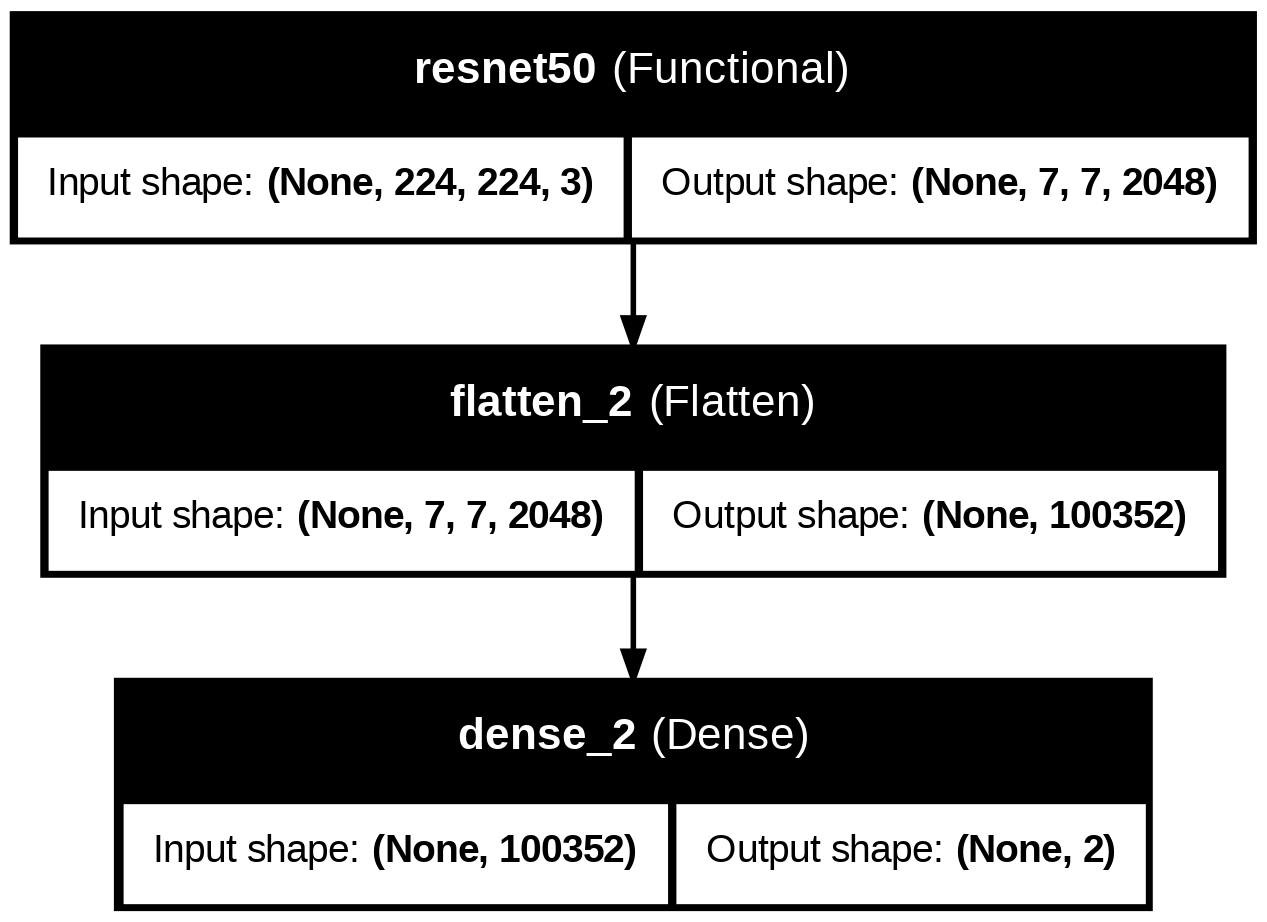

In [37]:
# obtaining a pictorial representation of the network
from tensorflow.keras.utils import plot_model
plot_model(model,  show_shapes=True, show_layer_names=True)

In [38]:
# training the network
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 29s 143ms/step - acc: 0.7342 - loss: 0.5226 - val_acc: 0.8250 - val_loss: 0.3859
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - acc: 0.8042 - loss: 0.4144 - val_acc: 0.8350 - val_loss: 0.3727
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step - acc: 0.8360 - loss: 0.3684 - val_acc: 0.8800 - val_loss: 0.2970
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 74ms/step - acc: 0.8342 - loss: 0.3653 - val_acc: 0.9100 - val_loss: 0.2565
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 69ms/step - acc: 0.8401 - loss: 0.3498 - val_acc: 0.9200 - val_loss: 0.2491
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 63ms/step - acc: 0.8464 - loss: 0.3439 - val_acc: 0.9150 - val_loss: 0.2321
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - acc: 0.8664 - loss: 0.3097 - val_acc: 0.9150 - val_loss: 0.2578
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step - acc: 0.8714 - loss: 0.3070 - val_acc: 0.9300 - val_loss: 0.2407
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 8s 74

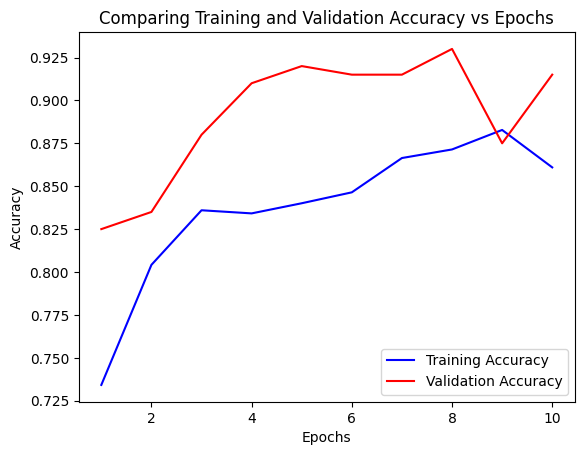

In [39]:
# extracting the model accuracy against epochs
ta = history.history['acc']
va = history.history['val_acc']
epochs = range(1,11)

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'b', label='Training Accuracy')
plt.plot(epochs, va, 'r', label='Validation Accuracy')
plt.title('Comparing Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

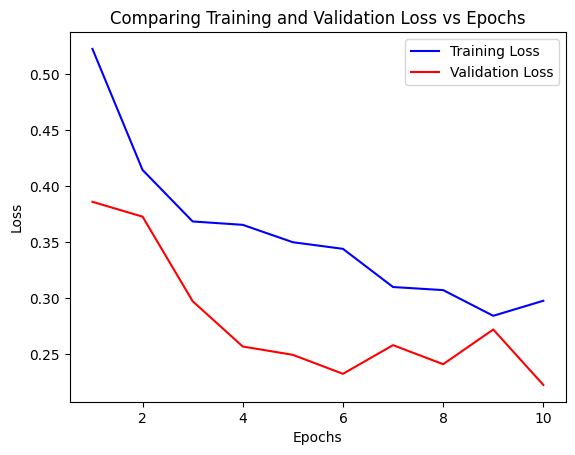

In [40]:
# extracting the model loss against epochs
tl = history.history['loss']
vl = history.history['val_loss']
epochs = range(1,11)

# plotting the losses
plt.figure()
plt.plot(epochs, tl, 'b', label='Training Loss')
plt.plot(epochs, vl, 'r', label='Validation Loss')
plt.title('Comparing Training and Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [42]:
# evaluating the model on the testing set
print(str.format('Accuracy on Test Set: {:.2f}%', model.evaluate(test_generator)[1]*100))

InvalidArgumentError: Graph execution error:

Detected at node sequential_2_1/dense_2_1/MatMul defined at (most recent call last):
<stack traces unavailable>
Matrix size-incompatible: In[0]: [20,204800], In[1]: [100352,2]

Stack trace for op definition: 
File "<frozen runpy>", line 198, in _run_module_as_main
File "<frozen runpy>", line 88, in _run_code
File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start
File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever
File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once
File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run
File "/usr/local/lib/python3.12/dist-packa

**EfficientNetB0**

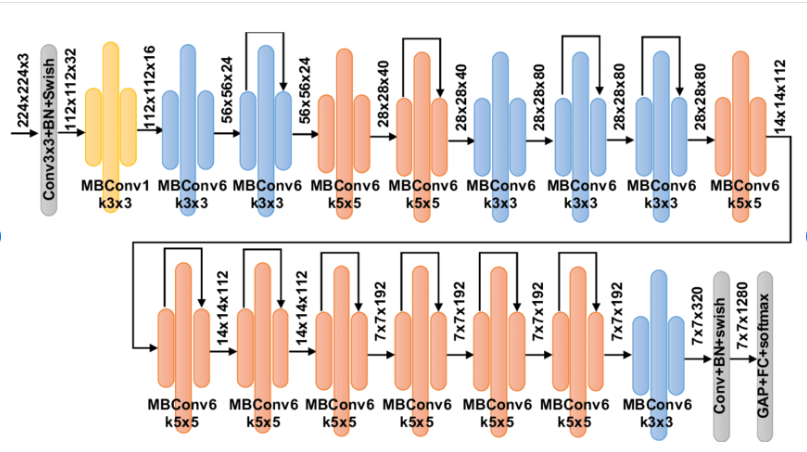

To begin, we implement the previously created data generators to generate the train, test, and validation sets and resize the images to 224x224 for the network implementation.

In [43]:
# flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224), # resclaing the images to 224 x 224
        batch_size=20,
        class_mode='categorical')

Found 2201 images belonging to 2 classes.


In [44]:
# flow validation images in batches of 20 using val_datagen generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224), # resclaing the images to 224 x 224
    batch_size=20,
    class_mode='categorical'
)

Found 200 images belonging to 2 classes.


In [45]:
# flow testing images in batches of 20 using test_datagen generator
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224), # resclaing the images to 224 x 224
        batch_size=20,
        class_mode='categorical')

Found 260 images belonging to 2 classes.


In [46]:
# importing the network
from keras.applications.efficientnet import EfficientNetB0
base_model = EfficientNetB0(input_shape=(224,224,3), weights='imagenet', include_top=False)
base_model.trainable = False # freezing the layers
base_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_6[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [47]:
# adding a deep neural network to make predictions
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(2, activation='sigmoid')
])
model.summary()

# compiling the network
model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), metrics = ['acc'])

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │       125,442 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,175,013 (15.93 MB)

 Trainable params: 125,442 (490.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

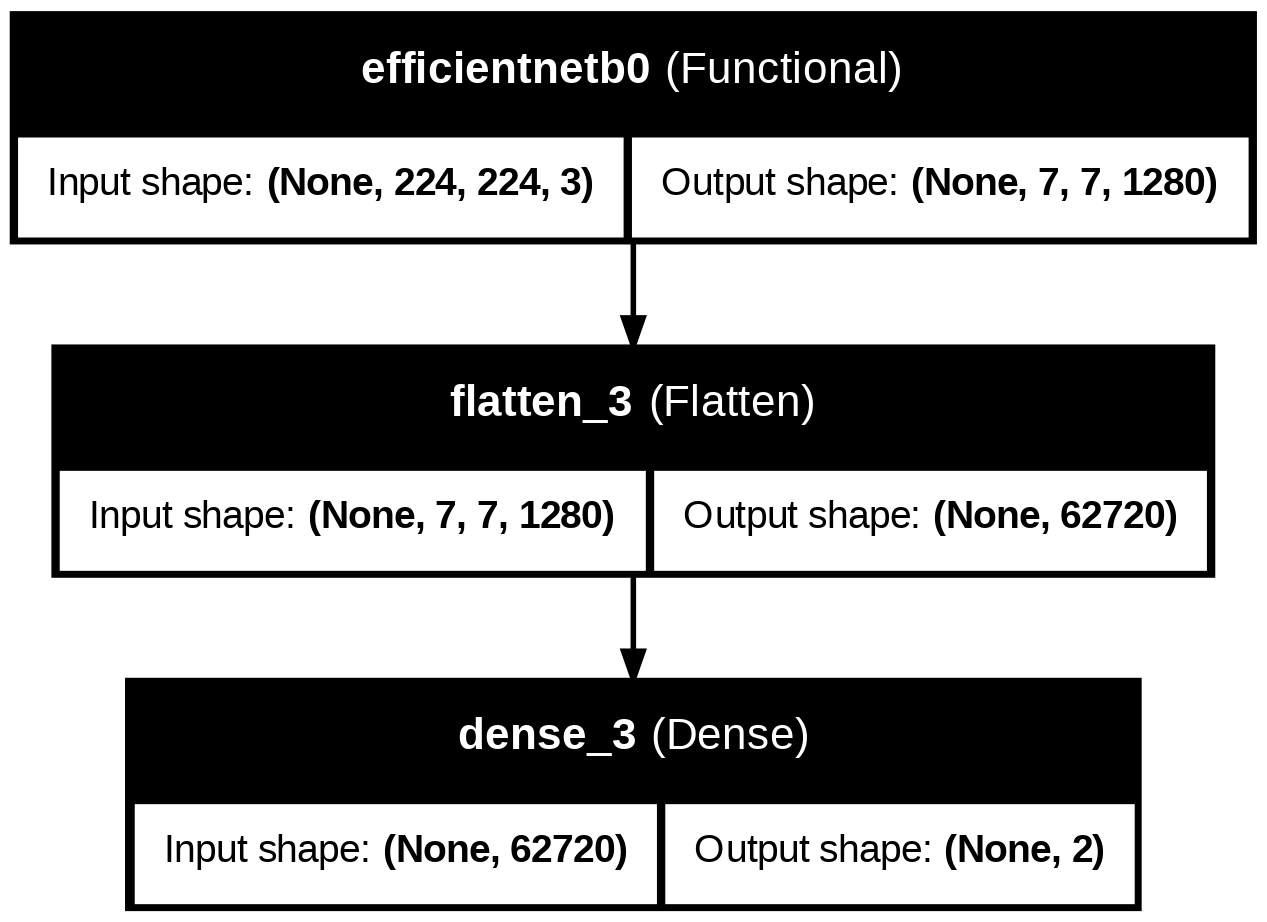

In [48]:
# obtaining a pictorial representation of the network
from tensorflow.keras.utils import plot_model
plot_model(model,  show_shapes=True, show_layer_names=True)

After that, we train the model on the training data generator with number of epochs set to 10 (optimum value set after trial and error of various combinations of accuracy and loss) and validation data to be used from the validation data generator.

In [49]:
# training the network
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 66s 318ms/step - acc: 0.5175 - loss: 0.7877 - val_acc: 0.5150 - val_loss: 0.6844
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - acc: 0.5679 - loss: 0.7082 - val_acc: 0.5600 - val_loss: 0.6519
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - acc: 0.5729 - loss: 0.6867 - val_acc: 0.5000 - val_loss: 0.8172
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - acc: 0.5852 - loss: 0.6769 - val_acc: 0.5100 - val_loss: 0.8285
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - acc: 0.6052 - loss: 0.6699 - val_acc: 0.5450 - val_loss: 0.6928
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - acc: 0.6265 - loss: 0.6276 - val_acc: 0.6400 - val_loss: 0.6070
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - acc: 0.5729 - loss: 0.7133 - val_acc: 0.5850 - val_loss: 0.5905
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - acc: 0.6297 - loss: 0.6445 - val_acc: 0.5600 - val_loss: 0.6920
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 45m

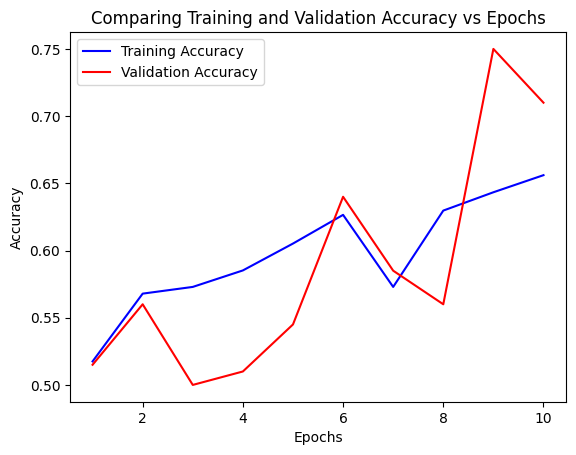

In [50]:
# extracting the model accuracy against epochs
ta = history.history['acc']
va = history.history['val_acc']
epochs = range(1,11)

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'b', label='Training Accuracy')
plt.plot(epochs, va, 'r', label='Validation Accuracy')
plt.title('Comparing Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

As we can see, the training and validation accuracies donot have a significant trend, however, the validation accuracy fluctuates a lot. There is sometimes a significant difference and sometimes a negligible difference between the two.

Next, we compare the training and validation losses. To do this, we use the history attribute and extract the losses of the models. Next, we plot it against the number of epochs using functions from the MatPlotLib library.

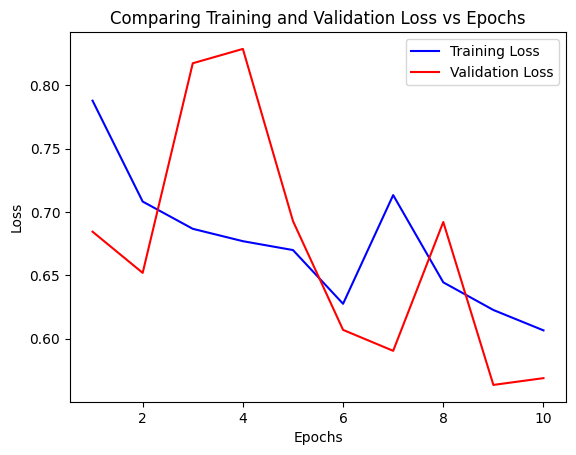

In [51]:
# extracting the model loss against epochs
tl = history.history['loss']
vl = history.history['val_loss']
epochs = range(1,11)

# plotting the losses
plt.figure()
plt.plot(epochs, tl, 'b', label='Training Loss')
plt.plot(epochs, vl, 'r', label='Validation Loss')
plt.title('Comparing Training and Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

As we can see, there is a slight downward trend in both the training and validation loss, and fluctuations are present in both. There is also some difference between the two.

To evaluate the performance of the model on the test set, we use the evaluate() function and print the model's accuracy on the testing set.

In [53]:
# evaluating the model on the testing set
print(str.format('Accuracy on Test Set: {:.2f}%', model.evaluate(test_generator)[1]*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - acc: 0.6846 - loss: 0.5812
Accuracy on Test Set: 68.46%


**MobileNetV2**

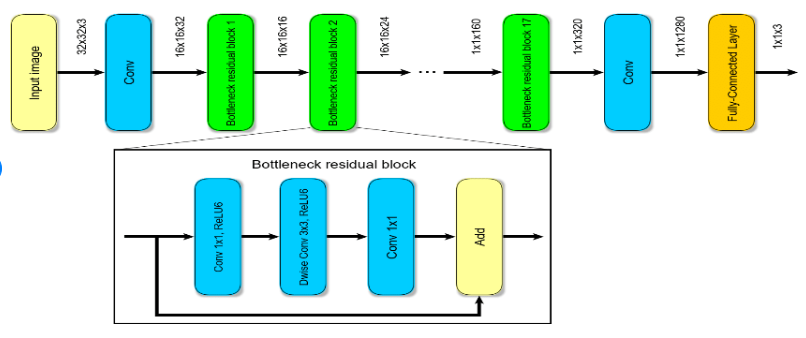

In [54]:
# flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow_from_directory(
        train_dir,
        target_size=(224, 224), # resclaing the images to 224 x 224
        batch_size=20,
        class_mode='categorical')

Found 2201 images belonging to 2 classes.


In [56]:
# flow validation images in batches of 20 using val_datagen generator
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224), # resclaing the images to 224 x 224
    batch_size=20,
    class_mode='categorical'
)

Found 200 images belonging to 2 classes.


In [57]:
# flow testing images in batches of 20 using test_datagen generator
test_generator = test_datagen.flow_from_directory(
        test_dir,
        target_size=(224, 224), # resclaing the images to 224 x 224
        batch_size=20,
        class_mode='categorical')

Found 260 images belonging to 2 classes.


*Next*, we use the concept of Transfer Learning to use MobileNetV2's pre-trained weights and biases for image classification. To do this, we import the base model of MobileNetV2 from the Keras library.

In [58]:
# importing the network
from keras.applications.mobilenet_v2 import MobileNetV2
base_model = MobileNetV2(input_shape=(224,224,3), weights='imagenet', include_top=False)
base_model.trainable = False # freezing the layers
base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_8[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [59]:
# adding a deep neural network to make predictions
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(2, activation='sigmoid')
])
model.summary()

# compiling the network
model.compile(loss = 'categorical_crossentropy', optimizer = tf.keras.optimizers.Adam(learning_rate = 0.0001), metrics = ['acc'])

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │       125,442 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,383,426 (9.09 MB)

 Trainable params: 125,442 (490.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

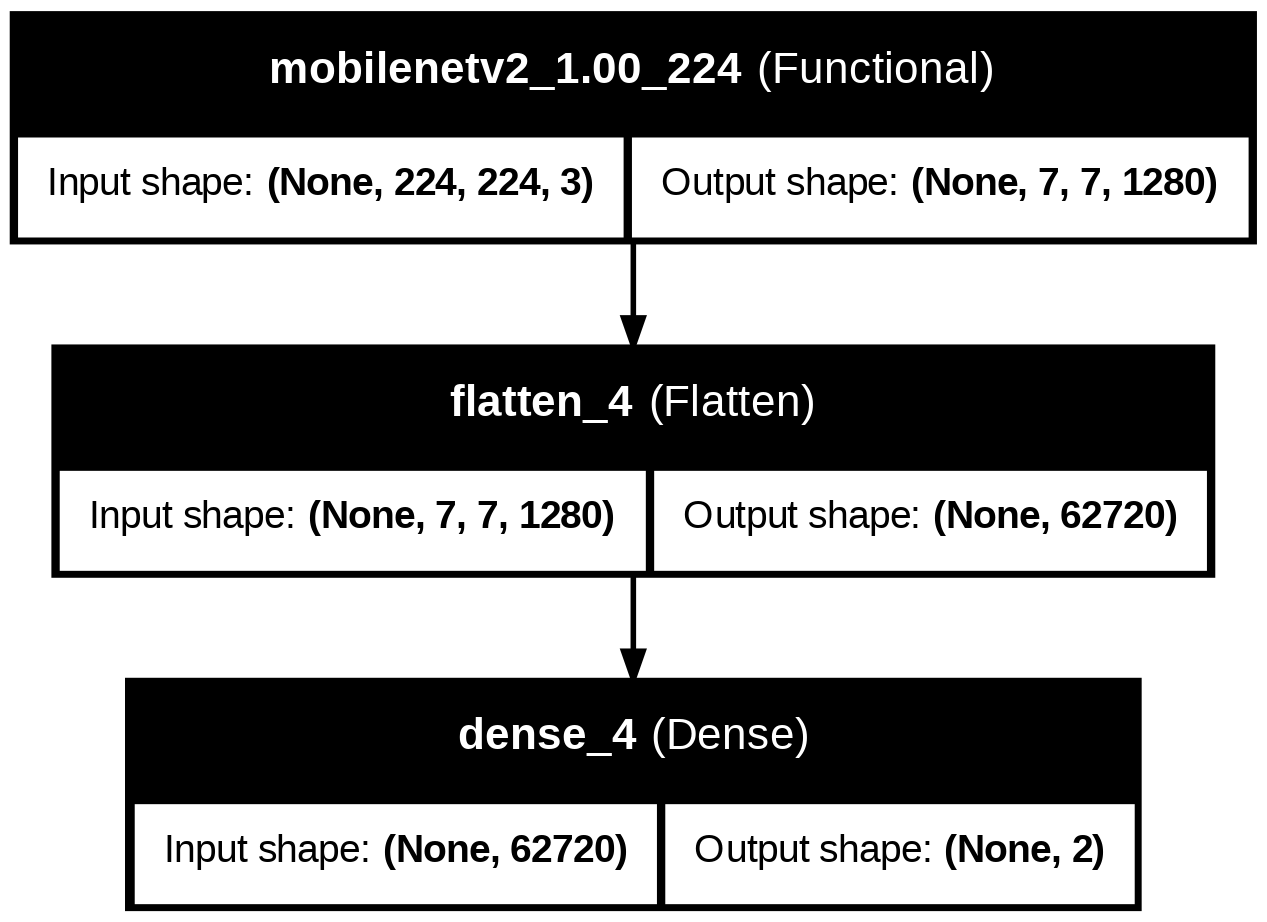

In [60]:
# obtaining a pictorial representation of the network
from tensorflow.keras.utils import plot_model
plot_model(model,  show_shapes=True, show_layer_names=True)

In [61]:
# training the network
history = model.fit(train_generator, epochs=10, validation_data=val_generator)

Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 37s 190ms/step - acc: 0.9650 - loss: 0.1017 - val_acc: 0.9700 - val_loss: 0.0989
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - acc: 0.9982 - loss: 0.0065 - val_acc: 0.9900 - val_loss: 0.0215
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - acc: 1.0000 - loss: 6.5877e-04 - val_acc: 0.9900 - val_loss: 0.0211
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - acc: 1.0000 - loss: 3.3652e-04 - val_acc: 0.9900 - val_loss: 0.0233
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - acc: 1.0000 - loss: 2.4964e-04 - val_acc: 0.9900 - val_loss: 0.0229
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - acc: 1.0000 - loss: 2.0745e-04 - val_acc: 0.9900 - val_loss: 0.0230
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - acc: 1.0000 - loss: 1.7565e-04 - val_acc: 0.9900 - val_loss: 0.0228
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - acc: 1.0000 - loss: 1.5195e-04 - val_acc: 0.9900 - val_loss: 0.0228
Epoch 9/10
111/111 ━━━

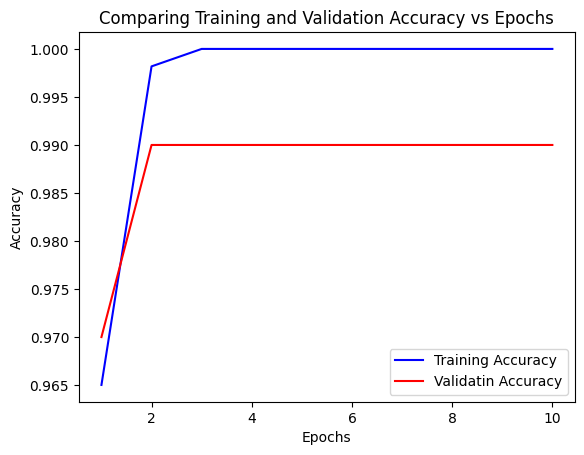

In [62]:
# extracting the model accuracy against epochs
ta = history.history['acc']
va = history.history['val_acc']
epochs = range(1,11)

# plotting the accuracies
plt.figure()
plt.plot(epochs, ta, 'b', label='Training Accuracy')
plt.plot(epochs, va, 'r', label='Validatin Accuracy')
plt.title('Comparing Training and Validation Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

As we can see, the training accuracy increases sharply, and then plateaus starting low, whereas the validation accuracy increases slightly and then plateaus starting high. There is not much difference between the two.

Next, we compare the training and validation losses. To do this, we use the history attribute and extract the losses of the models. Next, we plot it against the number of epochs using functions from the MatPlotLib library.

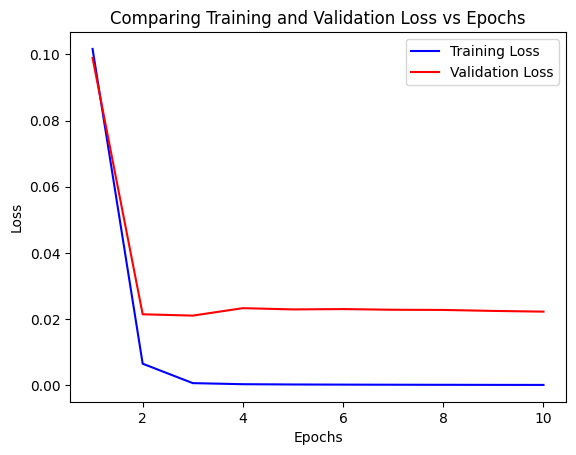

In [63]:
# extracting the model loss against epochs
tl = history.history['loss']
vl = history.history['val_loss']
epochs = range(1,11)

# plotting the losses
plt.figure()
plt.plot(epochs, tl, 'b', label='Training Loss')
plt.plot(epochs, vl, 'r', label='Validation Loss')
plt.title('Comparing Training and Validation Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

As we can see, the training loss decreases sharply and then plateuas startin high, whereas the validation loss remains almost constant. There is not much difference between the two.

To evaluate the performance of the model on the test set, we use the evaluate() function and print the model's accuracy on the testing set.

In [64]:
# evaluating the model on the testing set
print(str.format('Accuracy on Test Set: {:.2f}%', model.evaluate(test_generator)[1]*100))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - acc: 0.9885 - loss: 0.0808
Accuracy on Test Set: 98.85%
